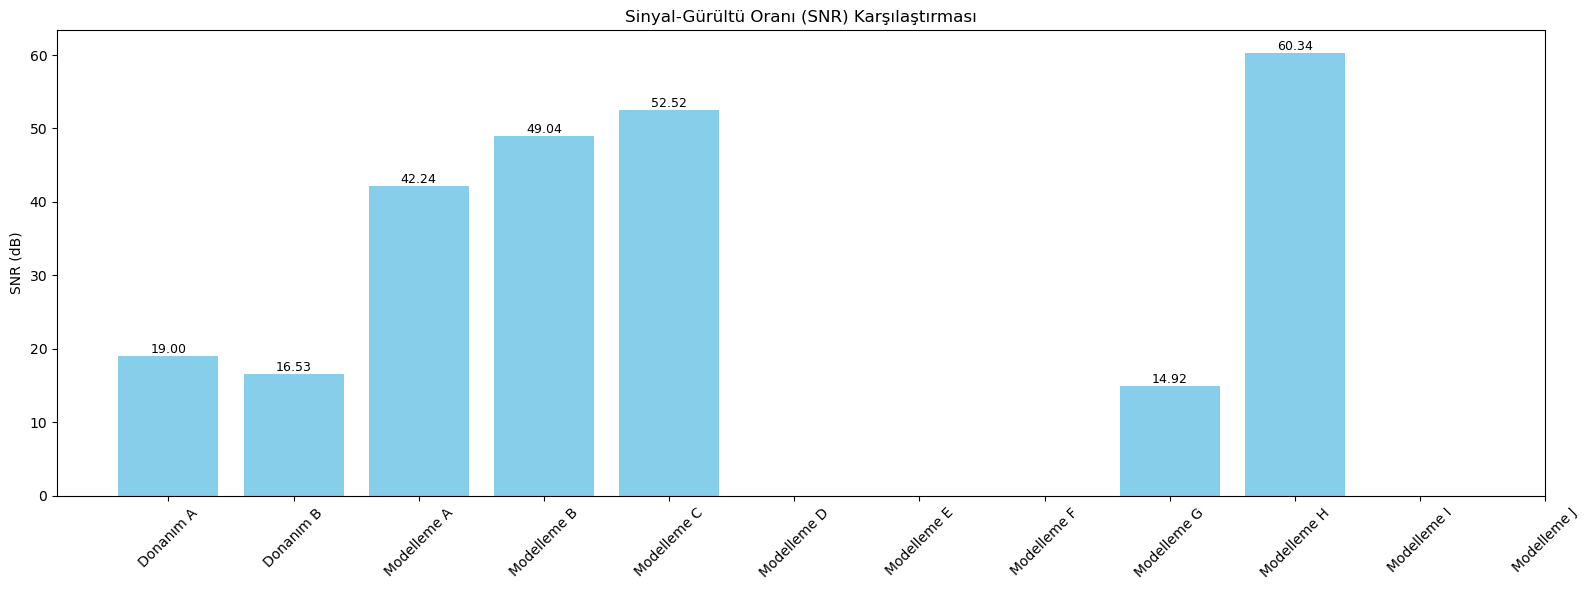

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import librosa
import librosa.display
import pyloudnorm as pyln
import IPython.display as ipd
from scipy import signal

# Ses dosyalarının yolları
audio_files = [
    "/Users/nazimerensahin/Desktop/processed/teletronix_white_noise.wav",
    "/Users/nazimerensahin/Desktop/processed/urei_white_noise.wav",
    "/Users/nazimerensahin/Desktop/processed/uad_gray_white_noise.wav",
    "/Users/nazimerensahin/Desktop/processed/uad_silver_white_noise.wav",
    "/Users/nazimerensahin/Desktop/processed/uad_tube_white_noise.wav",
    "/Users/nazimerensahin/Desktop/processed/waves_cla-2a_white_noise.wav",
    "/Users/nazimerensahin/Desktop/processed/ikm_white-2a_white_noise.wav",
    "/Users/nazimerensahin/Desktop/processed/ni_softube_vc-2a_white_noise.wav",
    "/Users/nazimerensahin/Desktop/processed/ss_fg-2a_white_noise.wav",
    "/Users/nazimerensahin/Desktop/processed/bra_vla-2a_white_noise.wav",
    "/Users/nazimerensahin/Desktop/processed/overloud_gem-comp-la_white_noise.wav",
    "/Users/nazimerensahin/Desktop/processed/ao_lala_white_noise.wav",
]

# Etiketler
audio_labels = [
    "Donanım A",
    "Donanım B",
    "Modelleme A",
    "Modelleme B",
    "Modelleme C",
    "Modelleme D",
    "Modelleme E",
    "Modelleme F",
    "Modelleme G",
    "Modelleme H",
    "Modelleme I",
    "Modelleme J",
]

# SNR hesaplama fonksiyonu
def calculate_snr(signal, sr):
    frame_length = int(sr * 0.05)
    hop_length = frame_length // 2
    rms_energy = librosa.feature.rms(y=signal, frame_length=frame_length, hop_length=hop_length)[0]
    threshold = np.percentile(rms_energy, 20)
    noise_indices = rms_energy < threshold

    frame_times = librosa.frames_to_time(np.arange(len(rms_energy)), sr=sr, hop_length=hop_length)
    noise_signal = np.zeros_like(signal)

    for i, frame_time in enumerate(frame_times):
        if not noise_indices[i]:
            continue
        start_sample = librosa.time_to_samples(frame_time, sr=sr)
        end_sample = librosa.time_to_samples(frame_time + 0.05, sr=sr)
        if end_sample > len(signal):
            end_sample = len(signal)
        if start_sample >= len(signal):
            continue
        noise_signal[start_sample:end_sample] = signal[start_sample:end_sample]

    signal_power = np.mean(signal ** 2)
    noise_power = np.mean(noise_signal ** 2)

    if noise_power == 0 or not np.isfinite(noise_power):
        return np.nan
    return 10 * np.log10(signal_power / noise_power)

# Grafiği çizme fonksiyonu
def plot_snr(signals, labels, sr):
    snr_values = [calculate_snr(signal, sr) for signal in signals]

    # Tüm değerlerin sayısı kadar bar çizilsin diye x konumları oluştur
    x = np.arange(len(labels))
    plt.figure(figsize=(16, 6))
    bars = plt.bar(x, snr_values, color='skyblue')
    plt.title("Sinyal-Gürültü Oranı (SNR) Karşılaştırması")
    plt.ylabel("SNR (dB)")
    plt.xticks(x, labels, rotation=45)

    for bar, snr in zip(bars, snr_values):
        height = bar.get_height()
        if np.isfinite(snr):
            plt.text(bar.get_x() + bar.get_width()/2.0, height, f"{snr:.2f}", ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

# Ses dosyalarını yükle
signals = []
sample_rates = []

for file in audio_files:
    signal, sr = librosa.load(file, sr=None)
    signals.append(signal)
    sample_rates.append(sr)

# SNR hesapla ve grafiği göster
plot_snr(signals=signals, labels=audio_labels, sr=sample_rates[0])
